In [2]:
%pip install pulp pandas matplotlib


Note: you may need to restart the kernel to use updated packages.


In [1]:
import pulp
print(pulp.__version__)

3.3.2


Status: Optimal
Minimum shipping cost: €1,570.00

Optimal Shipments:
Warehouse Store  Units
       W1    S2   60.0
       W1    S3   20.0
       W2    S1   50.0
       W2    S3   20.0
       W3    S4   60.0

Shadow prices (marginal cost of serving one more unit of demand):
  S1: €9.00 per unit
  S2: €9.00 per unit
  S3: €13.00 per unit
  S4: €5.00 per unit


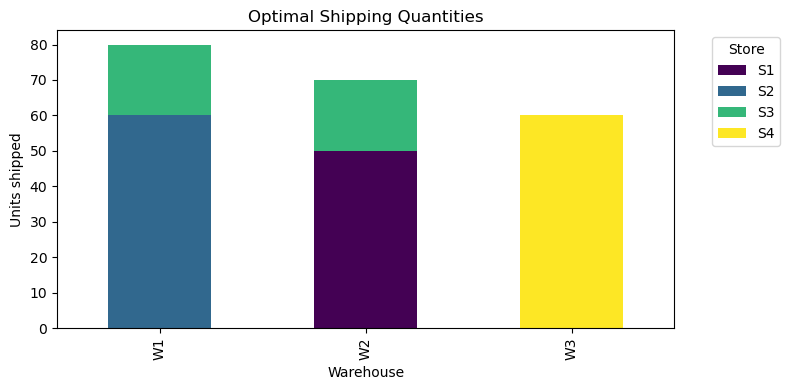

In [3]:
"""
Transportation Problem: Optimal Shipping with Dual Analysis
Minimize total shipping cost from 3 warehouses to 4 stores,
subject to supply and demand constraints.

Linear programming, PuLP, sensitivity analysis, data visualisation
"""

import pulp
import pandas as pd
import matplotlib.pyplot as plt


# 1. Data 

warehouses = ['W1', 'W2', 'W3']
stores = ['S1', 'S2', 'S3', 'S4']

supply = {'W1': 80, 'W2': 70, 'W3': 60}       # units available
demand = {'S1': 50, 'S2': 60, 'S3': 40, 'S4': 60}  # units required (sum = 210 = total supply)

# Unit shipping costs from each warehouse to each store
cost = {
    ('W1', 'S1'): 8, ('W1', 'S2'): 6, ('W1', 'S3'): 10, ('W1', 'S4'): 9,
    ('W2', 'S1'): 9, ('W2', 'S2'): 12, ('W2', 'S3'): 13, ('W2', 'S4'): 7,
    ('W3', 'S1'): 14, ('W3', 'S2'): 9, ('W3', 'S3'): 16, ('W3', 'S4'): 5,
}


# 2. Building the LP model

prob = pulp.LpProblem("Transportation_Problem", pulp.LpMinimize)

# Decision variables: amount shipped from warehouse w to store s
ship = pulp.LpVariable.dicts("ship",
                             [(w, s) for w in warehouses for s in stores],
                             lowBound=0, cat='Continuous')

# Objective: minimise total transportation cost
prob += pulp.lpSum([cost[w, s] * ship[w, s] for w in warehouses for s in stores])

# Supply constraints (each warehouse ships no more than its supply)
for w in warehouses:
    prob += pulp.lpSum([ship[w, s] for s in stores]) <= supply[w], f"Supply_{w}"

# Demand constraints (each store receives exactly its demand)
for s in stores:
    prob += pulp.lpSum([ship[w, s] for w in warehouses]) == demand[s], f"Demand_{s}"


# 3. Solve and output results

prob.solve(pulp.PULP_CBC_CMD(msg=False))
print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Minimum shipping cost: €{pulp.value(prob.objective):,.2f}\n")

# Optimal shipment plan

plan = [(w, s, pulp.value(ship[w, s])) for w in warehouses for s in stores
        if pulp.value(ship[w, s]) > 1e-5]
plan_df = pd.DataFrame(plan, columns=['Warehouse', 'Store', 'Units'])
print("Optimal Shipments:")
print(plan_df.to_string(index=False))


# 4. Shadow prices (dual values) for demand constraints

print("\nShadow prices (marginal cost of serving one more unit of demand):")
for s in stores:
    constraint_name = f"Demand_{s}"
    dual_value = prob.constraints[constraint_name].pi
    print(f"  {s}: €{dual_value:.2f} per unit")


# 5. Visualisation

fig, ax = plt.subplots(figsize=(8, 4))
plan_df.pivot(index='Warehouse', columns='Store', values='Units').plot(
    kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title("Optimal Shipping Quantities")
ax.set_ylabel("Units shipped")
ax.legend(title='Store', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("shipping_plan.png", dpi=150)
plt.show()